# 𓂃 ࣪˖ ִֶָ𐀔Butterfly Image Classification 𓂃 ࣪˖ ִֶཐི༏ཋྀ󠀮


In [1]:
import os, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import (
    EfficientNetB3, ResNet50V2, MobileNetV3Large, DenseNet121, InceptionV3
)
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as res_preprocess
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mob_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as den_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inc_preprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-06-05 14:30:07.527120: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780669807.721541      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780669807.780085      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780669808.207731      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780669808.207768      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780669808.207771      58 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : True


In [2]:
BASE      = '/kaggle/input/datasets/phucthaiv02/butterfly-image-classification'
TRAIN_DIR = f'{BASE}/train'
TEST_DIR  = f'{BASE}/test'
TRAIN_CSV = f'{BASE}/Training_set.csv'
TEST_CSV  = f'{BASE}/Testing_set.csv'

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30
VAL_SPLIT  = 0.15

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

train_df.columns = train_df.columns.str.strip().str.lower()
test_df.columns  = test_df.columns.str.strip().str.lower()

train_df['filepath'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filepath']  = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR,  x))

NUM_CLASSES = train_df['label'].nunique()
CLASS_NAMES = sorted(train_df['label'].unique().tolist())

print(f'Train samples : {len(train_df)}')
print(f'Test  samples : {len(test_df)}')
print(f'Classes       : {NUM_CLASSES}')
train_df.head()

Train samples : 6499
Test  samples : 2786
Classes       : 75


,filename,label,filepath
0,Image_1.jpg,SOUTHERN DOGFACE,/kaggle/input/datasets/phucthaiv02/butterfly-i...
1,Image_2.jpg,ADONIS,/kaggle/input/datasets/phucthaiv02/butterfly-i...
2,Image_3.jpg,BROWN SIPROETA,/kaggle/input/datasets/phucthaiv02/butterfly-i...
3,Image_4.jpg,MONARCH,/kaggle/input/datasets/phucthaiv02/butterfly-i...
4,Image_5.jpg,GREEN CELLED CATTLEHEART,/kaggle/input/datasets/phucthaiv02/butterfly-i...


## Exploratory Data Analysis (EDA)


In [3]:
le = LabelEncoder()
train_df['label_enc'] = le.fit_transform(train_df['label'])
print('Classes:', le.classes_[:5], '...')

Classes: ['ADONIS' 'AFRICAN GIANT SWALLOWTAIL' 'AMERICAN SNOOT' 'AN 88' 'APPOLLO'] ...


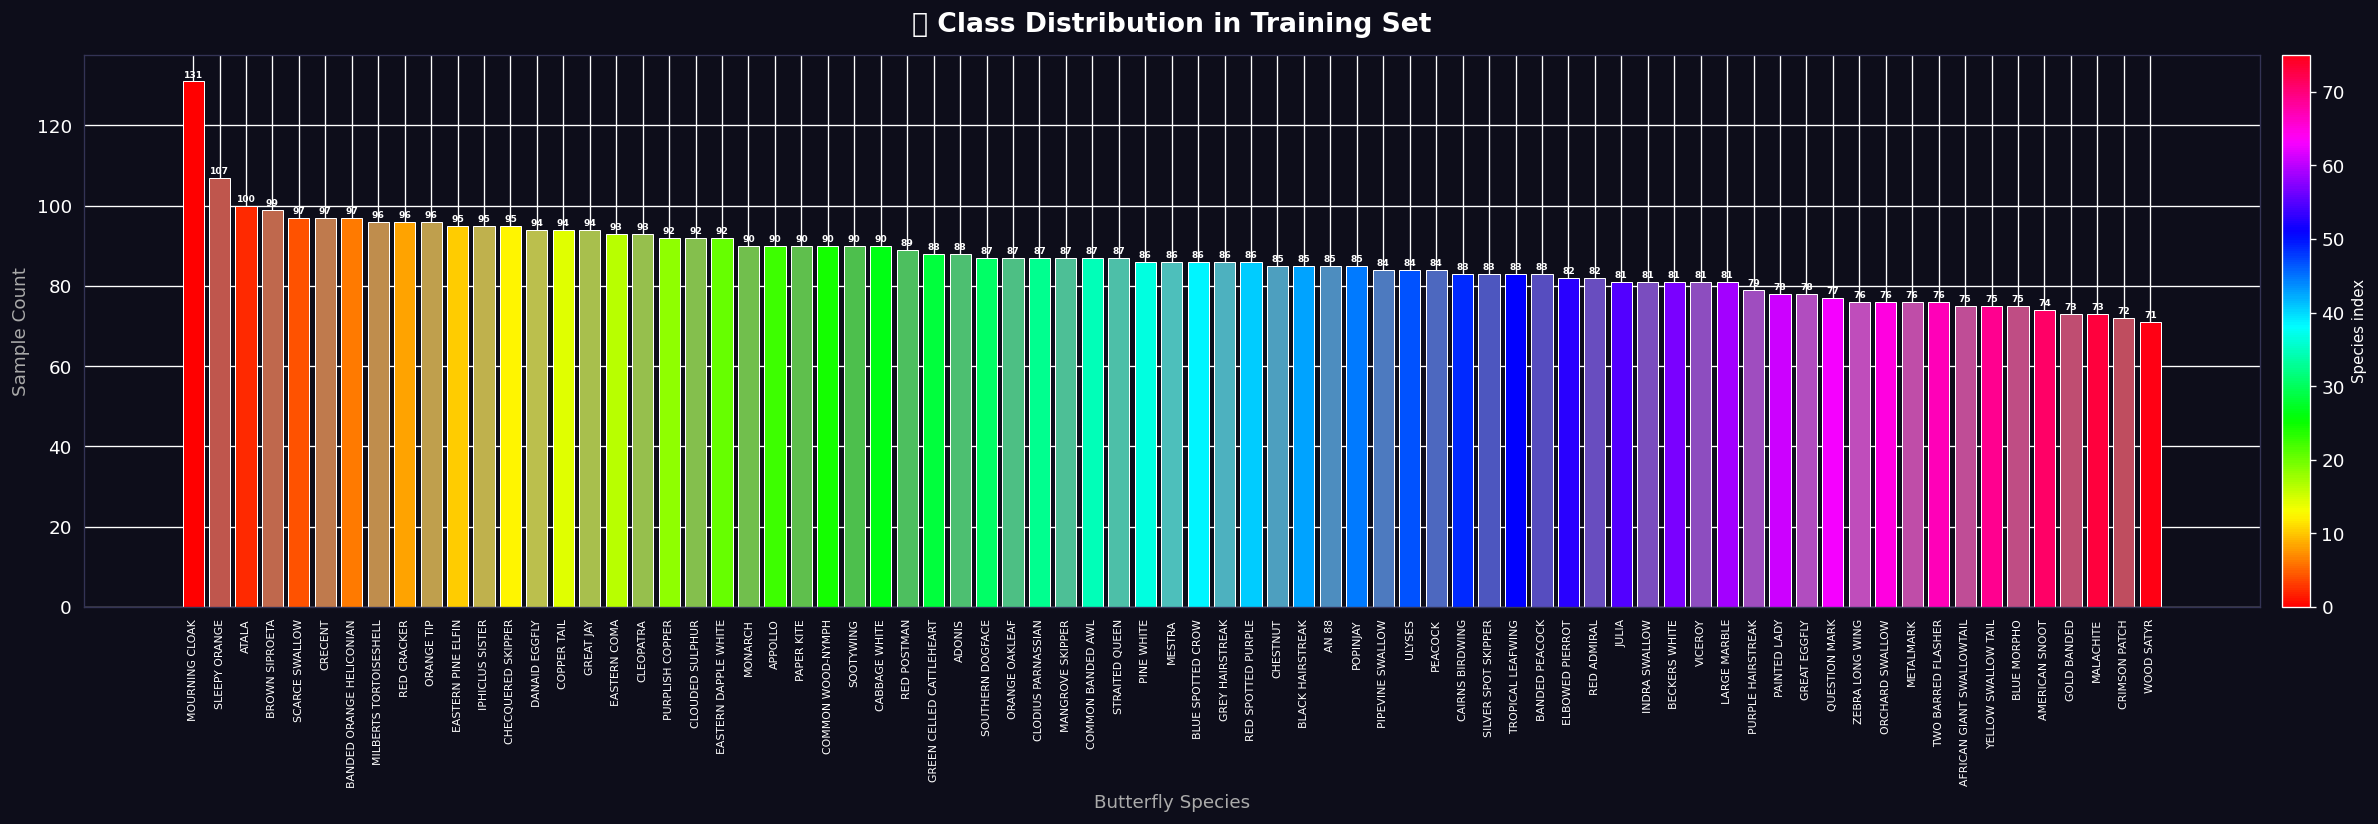

Min samples per class : 71
Max samples per class : 131
Mean samples per class: 86.7


In [4]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

counts = train_df['label'].value_counts().sort_values(ascending=False)
n = len(counts)

palette = [mcolors.hsv_to_rgb((i / n, 0.6 + 0.4 * (i % 2 == 0), 0.75 + 0.25 * (i % 2 == 0)))
           for i in range(n)]

fig, ax = plt.subplots(figsize=(20, 7))
bars = ax.bar(range(n), counts.values, color=palette, edgecolor='white', linewidth=0.6)

ax.set_facecolor('#0d0d1a')
fig.patch.set_facecolor('#0d0d1a')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=5.5, color='white', fontweight='bold')

ax.set_xticks(range(n))
ax.set_xticklabels(counts.index, rotation=90, fontsize=6.5, color='white')
ax.tick_params(colors='white')
ax.set_title('🦋 Class Distribution in Training Set', fontsize=16,
             fontweight='bold', color='white', pad=14)
ax.set_xlabel('Butterfly Species', color='#aaaaaa', fontsize=11)
ax.set_ylabel('Sample Count', color='#aaaaaa', fontsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

sm = cm.ScalarMappable(cmap='hsv', norm=mcolors.Normalize(vmin=0, vmax=n))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.015, pad=0.01)
cbar.set_label('Species index', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.show()

print(f'Min samples per class : {counts.min()}')
print(f'Max samples per class : {counts.max()}')
print(f'Mean samples per class: {counts.mean():.1f}')


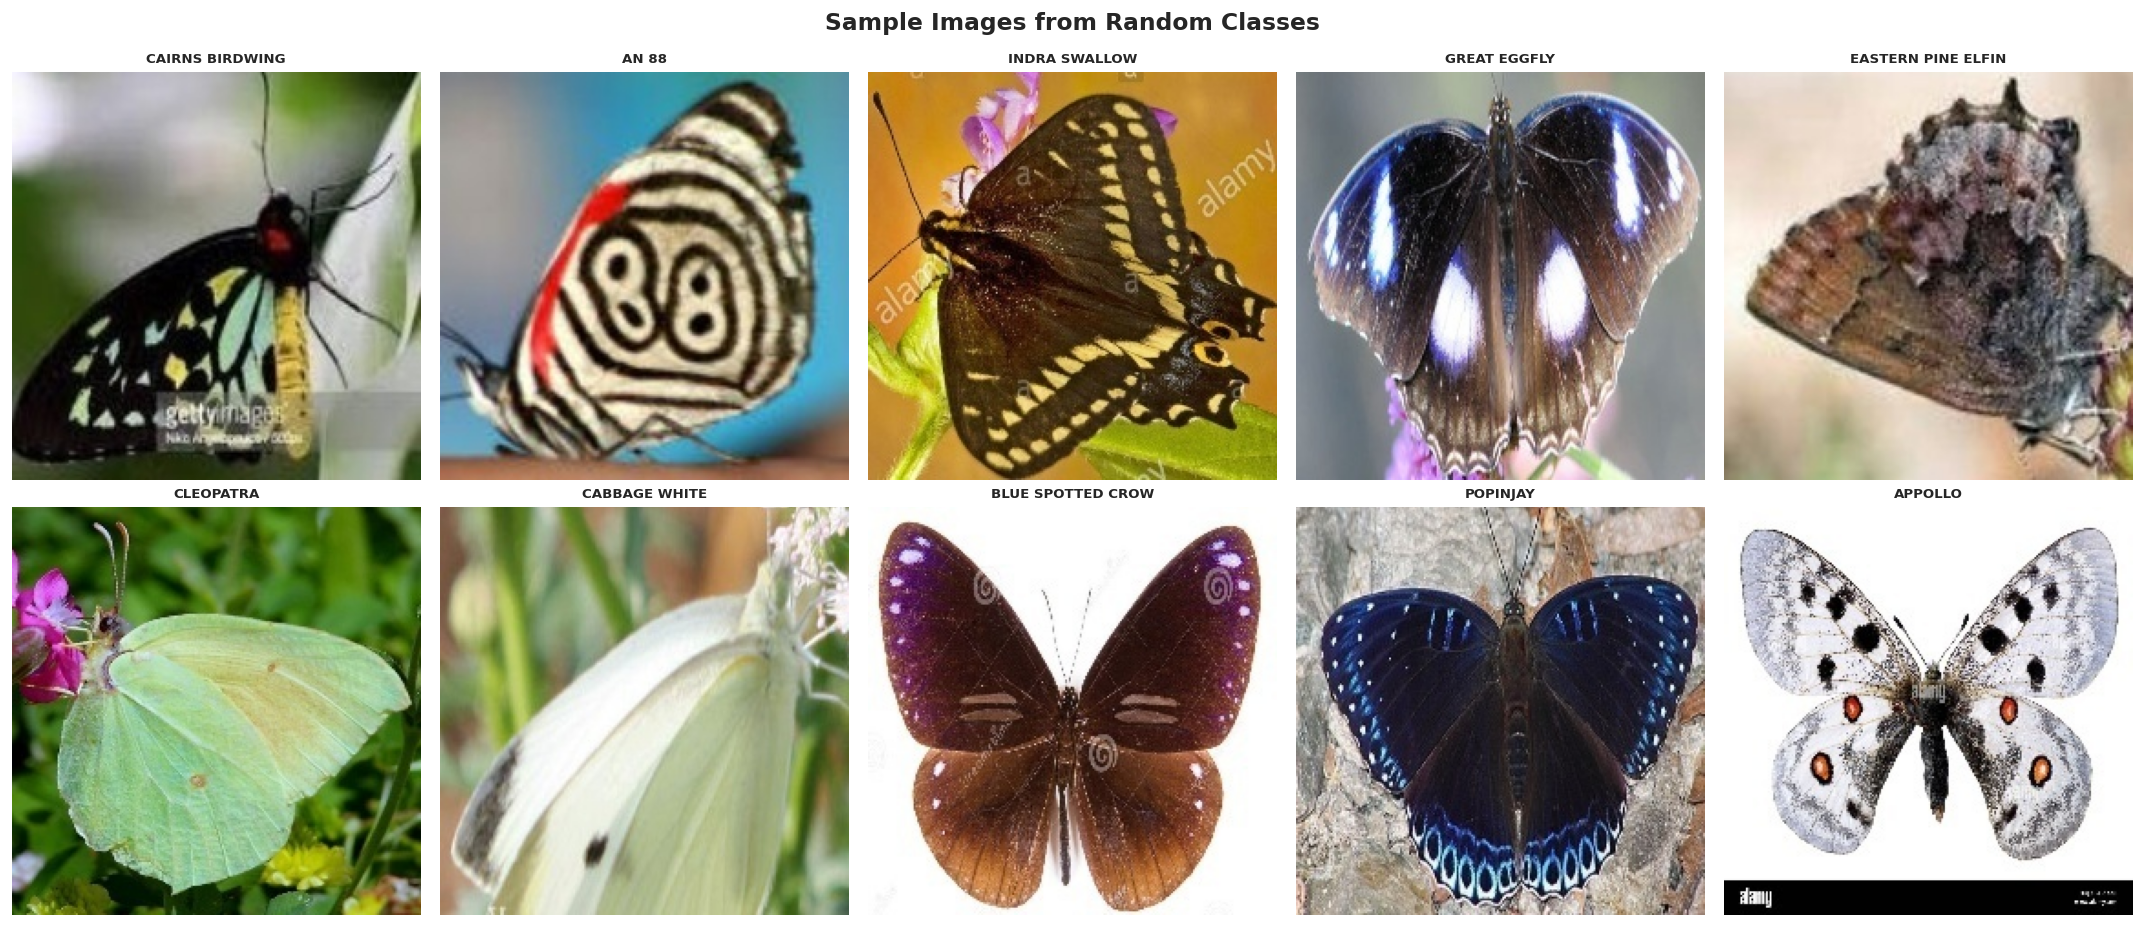

In [5]:
sample_classes = random.sample(CLASS_NAMES, min(10, NUM_CLASSES))
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, cls in enumerate(sample_classes):
    sample_row = train_df[train_df['label'] == cls].sample(1).iloc[0]
    img = Image.open(sample_row['filepath']).resize((224, 224))
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=8, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images from Random Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Reading image sizes:   0%|          | 0/500 [00:00<?, ?it/s]

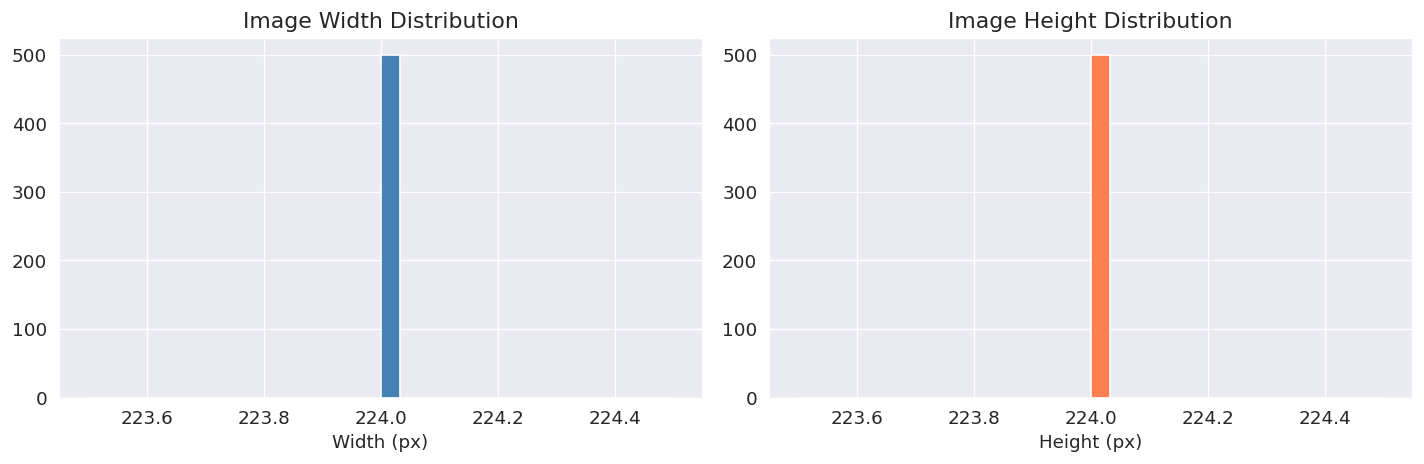

Avg width: 224px  |  Avg height: 224px


In [6]:
widths, heights = [], []
for fp in tqdm(train_df['filepath'].sample(min(500, len(train_df))), desc='Reading image sizes'):
    try:
        w, h = Image.open(fp).size
        widths.append(w)
        heights.append(h)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.show()
print(f'Avg width: {np.mean(widths):.0f}px  |  Avg height: {np.mean(heights):.0f}px')

## Data Generators


In [7]:
train_data, val_data = train_test_split(
    train_df, test_size=VAL_SPLIT, random_state=SEED, stratify=train_df['label']
)
print(f'Train size : {len(train_data)}')
print(f'Val size   : {len(val_data)}')

Train size : 5524
Val size   : 975


In [8]:
def make_generators(preprocess_fn, img_size=224):
    """Return (train_gen, val_gen, test_gen) for a given backbone preprocess function."""
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_dataframe(
        train_data,
        x_col='filepath',
        y_col='label',
        target_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=SEED
    )
    val_gen = val_datagen.flow_from_dataframe(
        val_data,
        x_col='filepath',
        y_col='label',
        target_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    test_gen = val_datagen.flow_from_dataframe(
        test_df,
        x_col='filepath',
        y_col=None,
        target_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        class_mode=None,
        shuffle=False
    )
    return train_gen, val_gen, test_gen


##  Data Augmentation

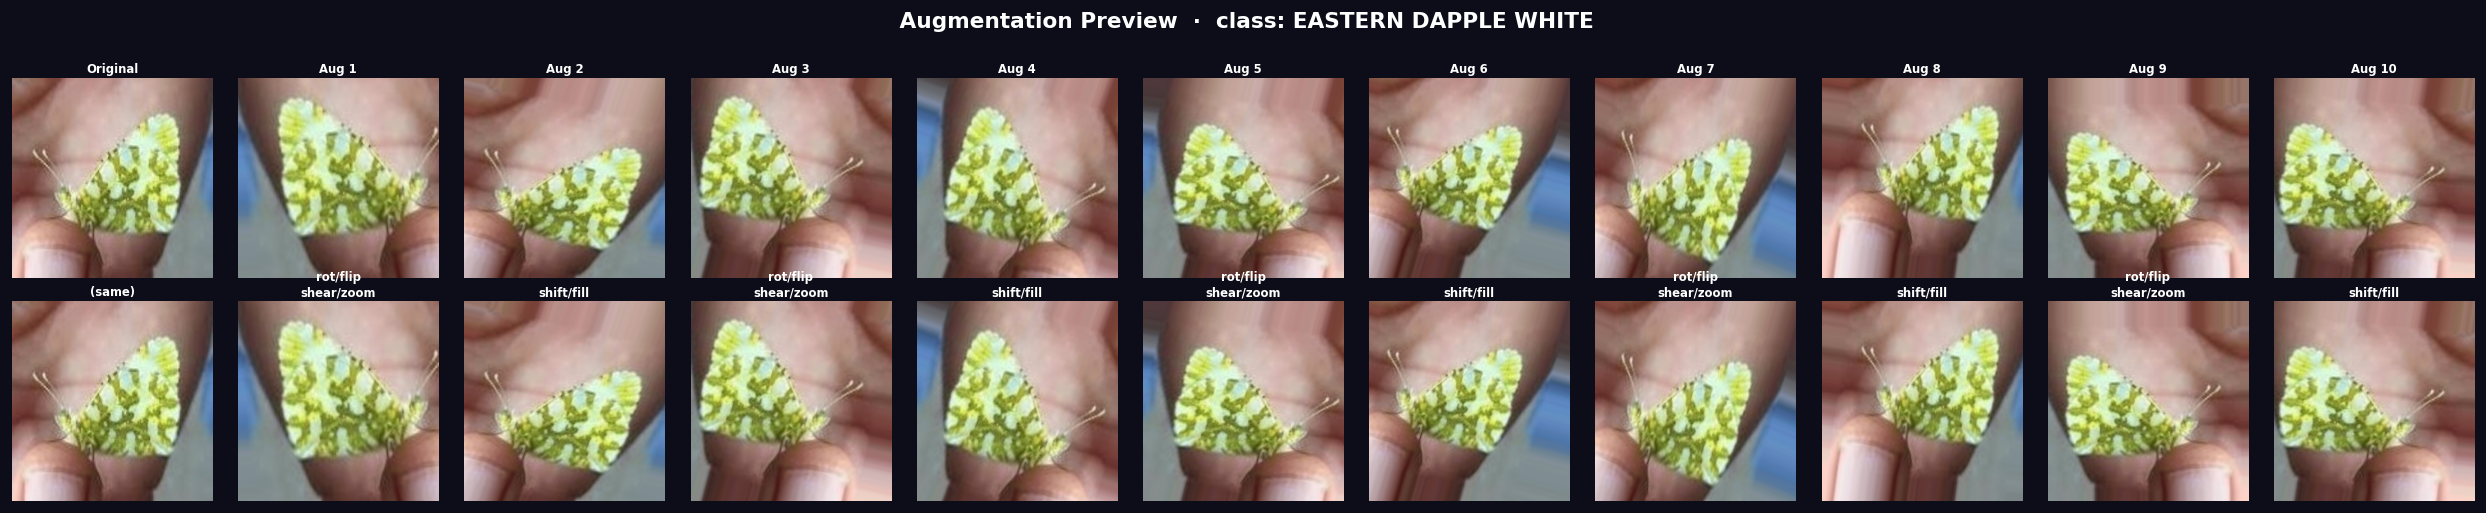

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator as _IDG, img_to_array, load_img

_aug_gen = _IDG(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

sample_row = train_data.sample(1, random_state=SEED).iloc[0]
orig_img   = load_img(sample_row['filepath'], target_size=(224, 224))
orig_arr   = img_to_array(orig_img)
orig_exp   = np.expand_dims(orig_arr, 0) 

n_aug = 10          
cols  = n_aug + 1   

fig, axes = plt.subplots(2, cols, figsize=(cols * 1.9, 4.2))
fig.patch.set_facecolor('#0d0d1a')

def _show(ax, img_arr, title, border_color):
    ax.imshow(img_arr.astype('uint8'))
    ax.set_title(title, fontsize=7, color='white', fontweight='bold', pad=3)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2)
    ax.set_facecolor('#0d0d1a')

_show(axes[0, 0], orig_arr, 'Original', '#00ff88')
_show(axes[1, 0], orig_arr, '(same)', '#00ff88')

aug_iter = _aug_gen.flow(orig_exp, batch_size=1, seed=SEED)
hues = [i / n_aug for i in range(n_aug)]
import matplotlib.colors as _mc

for i in range(n_aug):
    aug_batch = next(aug_iter)
    aug_img   = aug_batch[0]
    aug_img_disp = np.clip(aug_img, 0, 255)
    border = _mc.hsv_to_rgb((hues[i], 0.9, 1.0))

    label = f'Aug {i+1}'
    row_labels = [
        f'rot/flip\nshear/zoom',
        f'shift/fill',
    ]
    _show(axes[0, i + 1], aug_img_disp, label, border)
    _show(axes[1, i + 1], aug_img_disp, row_labels[i % 2], border)

for row, txt in zip([0, 1], ['▶  Augmented training views (Row 1)',
                              '▶  Same augmented views — row 2 context']):
    axes[row, 0].set_ylabel(txt, color='#aaaaaa', fontsize=7, rotation=0,
                            labelpad=4, va='center', ha='right')

fig.suptitle(
    f' Augmentation Preview  ·  class: {sample_row["label"]}',
    fontsize=13, color='white', fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


## Build & Evaluate Model


In [10]:
def build_model(base_model_fn, preprocess_fn, img_size=224, model_name='Model'):
    """Build a transfer-learning model with a frozen backbone + custom head."""
    base = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False  

    inputs  = keras.Input(shape=(img_size, img_size, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(512, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def get_callbacks(model_name):
    os.makedirs('checkpoints', exist_ok=True)
    return [
        EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(
            f'checkpoints/{model_name}_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        )
    ]


def fine_tune_model(model, base_model_fn, train_gen, val_gen, unfreeze_layers=30):
    """Unfreeze top layers and fine-tune with a lower LR."""
    backbone = model.layers[1]
    backbone.trainable = True
    for layer in backbone.layers[:-unfreeze_layers]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history_ft = model.fit(
        train_gen,
        epochs=10,
        validation_data=val_gen,
        callbacks=[
            EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8)
        ],
        verbose=1
    )
    return history_ft


def evaluate_on_val(model, val_gen, model_name):
    """Evaluate model, print metrics and return results dict."""
    val_gen.reset()
    y_pred_prob = model.predict(val_gen, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = val_gen.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n── {model_name} ──')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')

    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}


def plot_history(history, model_name, fine_tune_history=None):
    """Plot training curves (optionally with fine-tuning phase)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for metric, ax in zip(['accuracy', 'loss'], axes):
        ax.plot(history.history[metric], label=f'Train {metric}')
        ax.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        if fine_tune_history:
            offset = len(history.history[metric])
            ax.plot(
                range(offset, offset + len(fine_tune_history.history[metric])),
                fine_tune_history.history[metric], '--', label=f'FT Train {metric}'
            )
            ax.plot(
                range(offset, offset + len(fine_tune_history.history[f'val_{metric}'])),
                fine_tune_history.history[f'val_{metric}'], '--', label=f'FT Val {metric}'
            )
        ax.set_title(f'{model_name} — {metric.capitalize()}')
        ax.set_xlabel('Epoch')
        ax.legend()

    plt.tight_layout()
    plt.show()


all_results = []

## Model 1 — EfficientNetB3


  MODEL 1 : EfficientNetB3
Found 5524 validated image filenames belonging to 75 classes.
Found 975 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.


I0000 00:00:1780670826.061636      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780670826.067729      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

153/173 ━━━━━━━━━━━━━━━━━━━━ 2:19 7s/step - accuracy: 0.3114 - loss: 3.0169

2026-06-05 15:06:09.361327: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:06:09.504112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:06:09.847204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:06:09.994487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:06:10.808644: E external/local_xla/xla/stream_

173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3323 - loss: 2.9009

2026-06-05 15:10:57.427870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:10:57.569706: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:10:57.900607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:10:58.047665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 15:10:58.830967: E external/local_xla/xla/stream_

173/173 ━━━━━━━━━━━━━━━━━━━━ 1422s 8s/step - accuracy: 0.5016 - loss: 1.9663 - val_accuracy: 0.7990 - val_loss: 1.1660 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 67s 388ms/step - accuracy: 0.7674 - loss: 0.8238 - val_accuracy: 0.8708 - val_loss: 0.5317 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 62s 359ms/step - accuracy: 0.8065 - loss: 0.6427 - val_accuracy: 0.8708 - val_loss: 0.4462 - learning_rate: 0.0010
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 64s 369ms/step - accuracy: 0.8402 - loss: 0.5350 - val_accuracy: 0.8903 - val_loss: 0.4319 - learning_rate: 0.0010
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 64s 367ms/step - accuracy: 0.8554 - loss: 0.4710 - val_accuracy: 0.8923 - val_loss: 0.3841 - learning_rate: 0.0010
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 62s 359ms/step - accuracy: 0.8718 - loss: 0.4206 - val_accuracy: 0.8923 - val_loss: 0.3977 - learning_rate: 0.0010
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 63s 362ms/step - accuracy: 0.8753 - loss: 

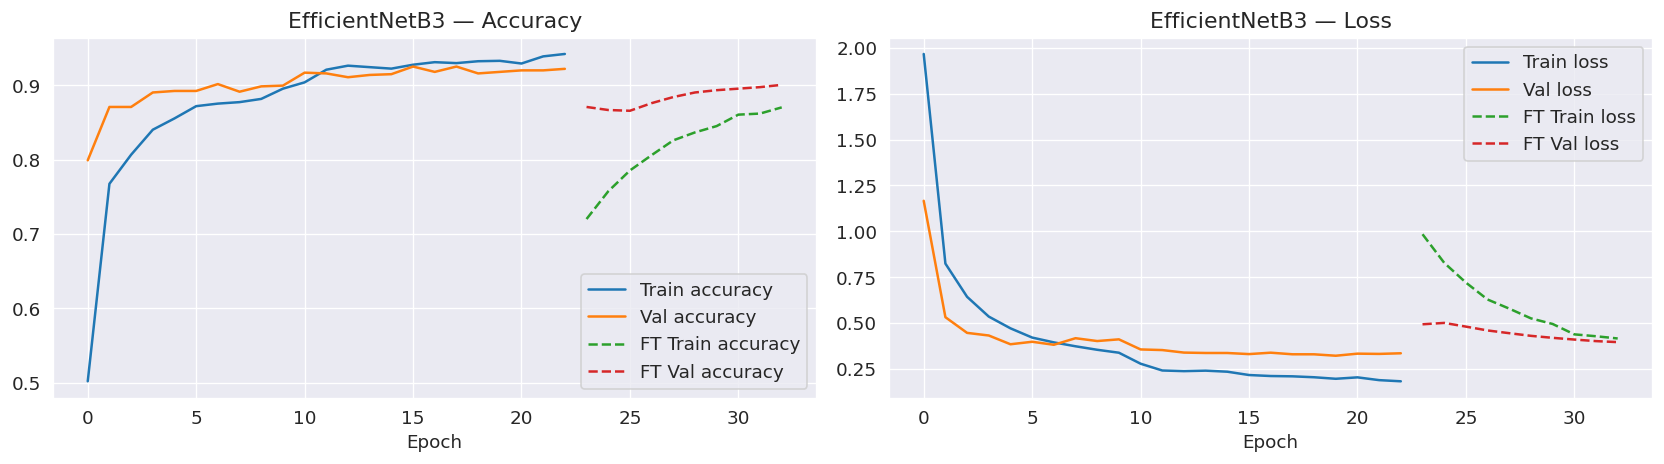


── EfficientNetB3 ──
  Accuracy  : 0.9005
  Precision : 0.9036
  Recall    : 0.9005
  F1-Score  : 0.8988


In [11]:
print('=' * 60)
print('  MODEL 1 : EfficientNetB3')
print('=' * 60)

train_gen_eff, val_gen_eff, test_gen_eff = make_generators(eff_preprocess, img_size=224)

model_eff = build_model(EfficientNetB3, eff_preprocess, img_size=224, model_name='EfficientNetB3')
model_eff.summary()

history_eff = model_eff.fit(
    train_gen_eff,
    epochs=EPOCHS,
    validation_data=val_gen_eff,
    callbacks=get_callbacks('EfficientNetB3'),
    verbose=1
)

history_eff_ft = fine_tune_model(model_eff, EfficientNetB3, train_gen_eff, val_gen_eff)

plot_history(history_eff, 'EfficientNetB3', history_eff_ft)
result_eff = evaluate_on_val(model_eff, val_gen_eff, 'EfficientNetB3')
all_results.append(result_eff)

## Model 2 — ResNet50V2


  MODEL 2 : ResNet50V2
Found 5524 validated image filenames belonging to 75 classes.
Found 975 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,662,603 (94.08 MB)

 Trainable params: 1,092,683 (4.17 MB)

 Non-trainable params: 23,569,920 (89.91 MB)

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 90s 443ms/step - accuracy: 0.5824 - loss: 1.7041 - val_accuracy: 0.8174 - val_loss: 0.7438 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 63s 367ms/step - accuracy: 0.7998 - loss: 0.6960 - val_accuracy: 0.8626 - val_loss: 0.5203 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 64s 370ms/step - accuracy: 0.8490 - loss: 0.5249 - val_accuracy: 0.8913 - val_loss: 0.4530 - learning_rate: 0.0010
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 63s 363ms/step - accuracy: 0.8671 - loss: 0.4345 - val_accuracy: 0.8800 - val_loss: 0.4407 - learning_rate: 0.0010
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 63s 364ms/step - accuracy: 0.8850 - loss: 0.3720 - val_accuracy: 0.8913 - val_loss: 0.4072 - learning_rate: 0.0010
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 63s 366ms/step - accuracy: 0.8954 - loss: 0.3332 - val_accuracy: 0.8923 - val_loss: 0.4026 - learning_rate: 0.0010
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 64s 370ms/step - accuracy: 0.9

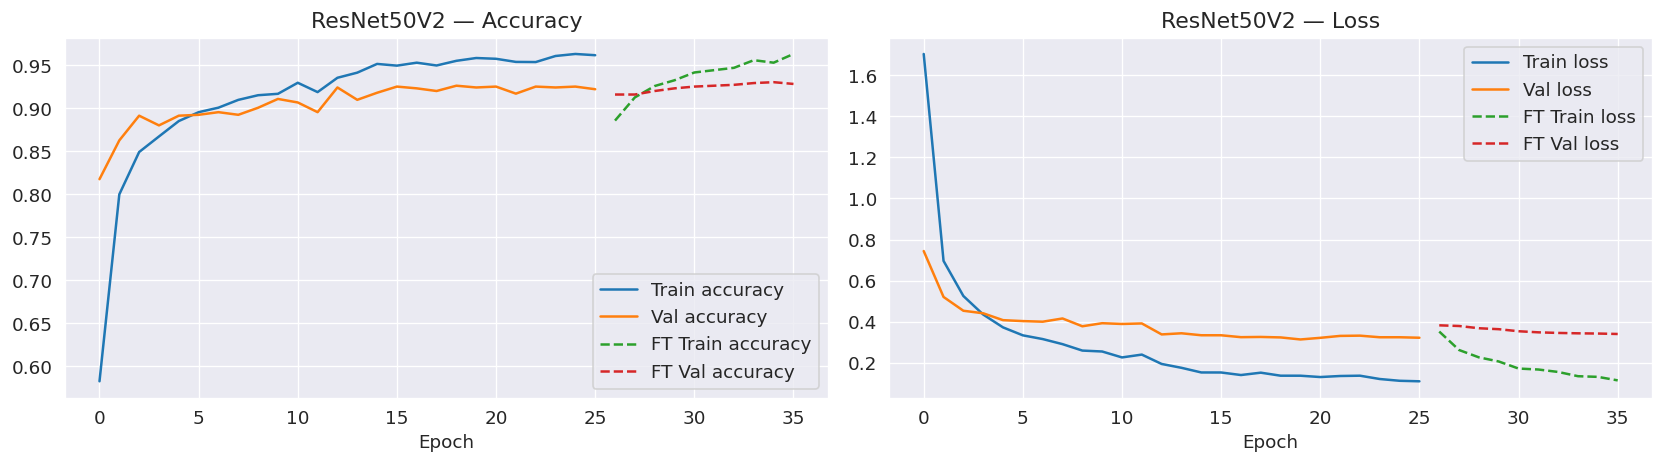


── ResNet50V2 ──
  Accuracy  : 0.9303
  Precision : 0.9339
  Recall    : 0.9303
  F1-Score  : 0.9297


In [12]:
print('=' * 60)
print('  MODEL 2 : ResNet50V2')
print('=' * 60)

train_gen_res, val_gen_res, test_gen_res = make_generators(res_preprocess, img_size=224)

model_res = build_model(ResNet50V2, res_preprocess, img_size=224, model_name='ResNet50V2')
model_res.summary()

history_res = model_res.fit(
    train_gen_res,
    epochs=EPOCHS,
    validation_data=val_gen_res,
    callbacks=get_callbacks('ResNet50V2'),
    verbose=1
)

history_res_ft = fine_tune_model(model_res, ResNet50V2, train_gen_res, val_gen_res)

plot_history(history_res, 'ResNet50V2', history_res_ft)
result_res = evaluate_on_val(model_res, val_gen_res, 'ResNet50V2')
all_results.append(result_res)

## Model 3 — MobileNetV3Large


  MODEL 3 : MobileNetV3Large
Found 5524 validated image filenames belonging to 75 classes.
Found 975 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       492,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,532,747 (13.48 MB)

 Trainable params: 533,451 (2.03 MB)

...

 23/173 ━━━━━━━━━━━━━━━━━━━━ 48s 326ms/step - accuracy: 0.0556 - loss: 4.7455

2026-06-05 16:32:18.165452: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 16:32:18.299885: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 16:32:18.612819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 16:32:18.750065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.3341 - loss: 2.9628

2026-06-05 16:33:25.820424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 16:33:25.954158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 16:33:26.261648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 16:33:26.398786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


173/173 ━━━━━━━━━━━━━━━━━━━━ 106s 505ms/step - accuracy: 0.5255 - loss: 1.9418 - val_accuracy: 0.8431 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 61s 350ms/step - accuracy: 0.7967 - loss: 0.7278 - val_accuracy: 0.8892 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 60s 348ms/step - accuracy: 0.8528 - loss: 0.5126 - val_accuracy: 0.9046 - val_loss: 0.4180 - learning_rate: 0.0010
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 122s 709ms/step - accuracy: 0.8738 - loss: 0.4184 - val_accuracy: 0.9005 - val_loss: 0.3797 - learning_rate: 0.0010
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 157s 909ms/step - accuracy: 0.8937 - loss: 0.3484 - val_accuracy: 0.9097 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 119s 691ms/step - accuracy: 0.9022 - loss: 0.3210 - val_accuracy: 0.8985 - val_loss: 0.3845 - learning_rate: 0.0010
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 129s 747ms/step - accuracy: 0.9035 - 

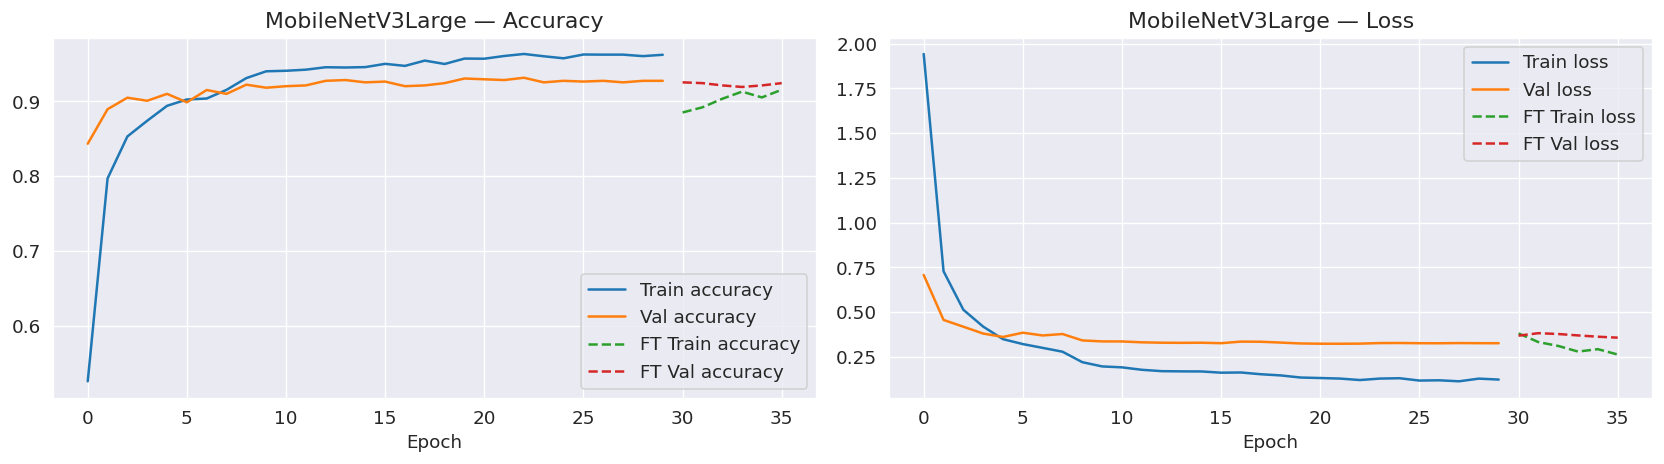


── MobileNetV3Large ──
  Accuracy  : 0.9251
  Precision : 0.9296
  Recall    : 0.9251
  F1-Score  : 0.9238


In [13]:
print('=' * 60)
print('  MODEL 3 : MobileNetV3Large')
print('=' * 60)

train_gen_mob, val_gen_mob, test_gen_mob = make_generators(mob_preprocess, img_size=224)

model_mob = build_model(MobileNetV3Large, mob_preprocess, img_size=224, model_name='MobileNetV3Large')
model_mob.summary()

history_mob = model_mob.fit(
    train_gen_mob,
    epochs=EPOCHS,
    validation_data=val_gen_mob,
    callbacks=get_callbacks('MobileNetV3Large'),
    verbose=1
)

history_mob_ft = fine_tune_model(model_mob, MobileNetV3Large, train_gen_mob, val_gen_mob)

plot_history(history_mob, 'MobileNetV3Large', history_mob_ft)
result_mob = evaluate_on_val(model_mob, val_gen_mob, 'MobileNetV3Large')
all_results.append(result_mob)

## Model 4 — DenseNet121


  MODEL 4 : DenseNet121
Found 5524 validated image filenames belonging to 75 classes.
Found 975 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,606,923 (29.02 MB)

 Trainable params: 566,347 (2.16 MB)

 Non-trainable params: 7,040,576 (26.86 MB)

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 129s 590ms/step - accuracy: 0.5109 - loss: 2.0036 - val_accuracy: 0.8338 - val_loss: 0.7489 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 66s 382ms/step - accuracy: 0.7967 - loss: 0.7312 - val_accuracy: 0.8821 - val_loss: 0.4506 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 64s 372ms/step - accuracy: 0.8454 - loss: 0.5313 - val_accuracy: 0.9046 - val_loss: 0.3792 - learning_rate: 0.0010
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 66s 380ms/step - accuracy: 0.8707 - loss: 0.4339 - val_accuracy: 0.9128 - val_loss: 0.3426 - learning_rate: 0.0010
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 63s 363ms/step - accuracy: 0.8825 - loss: 0.3828 - val_accuracy: 0.8954 - val_loss: 0.3489 - learning_rate: 0.0010
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 63s 365ms/step - accuracy: 0.8941 - loss: 0.3485 - val_accuracy: 0.9097 - val_loss: 0.3321 - learning_rate: 0.0010
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 66s 381ms/step - accuracy: 0.

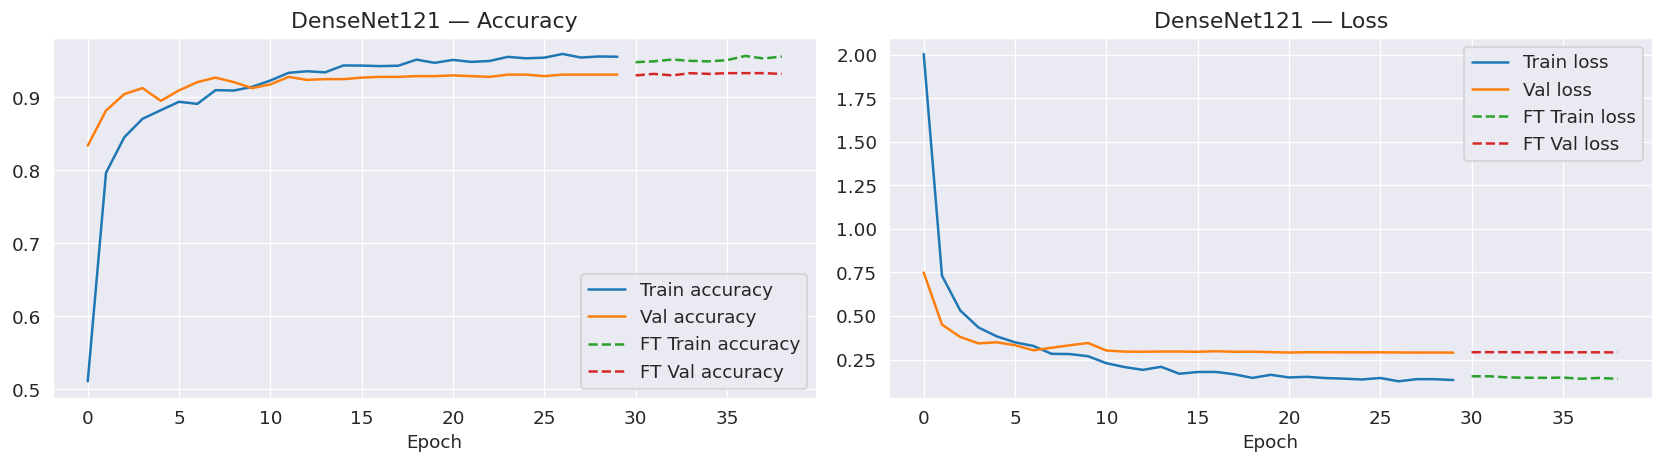


── DenseNet121 ──
  Accuracy  : 0.9333
  Precision : 0.9349
  Recall    : 0.9333
  F1-Score  : 0.9323


In [14]:
print('=' * 60)
print('  MODEL 4 : DenseNet121')
print('=' * 60)

train_gen_den, val_gen_den, test_gen_den = make_generators(den_preprocess, img_size=224)

model_den = build_model(DenseNet121, den_preprocess, img_size=224, model_name='DenseNet121')
model_den.summary()

history_den = model_den.fit(
    train_gen_den,
    epochs=EPOCHS,
    validation_data=val_gen_den,
    callbacks=get_callbacks('DenseNet121'),
    verbose=1
)

history_den_ft = fine_tune_model(model_den, DenseNet121, train_gen_den, val_gen_den)

plot_history(history_den, 'DenseNet121', history_den_ft)
result_den = evaluate_on_val(model_den, val_gen_den, 'DenseNet121')
all_results.append(result_den)

## Model 5 — InceptionV3


  MODEL 5 : InceptionV3  (img_size=299)
Found 5524 validated image filenames belonging to 75 classes.
Found 975 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,900,587 (87.36 MB)

 Trainable params: 1,092,683 (4.17 MB)

 Non-trainable params: 21,807,904 (83.19 MB)

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 151s 757ms/step - accuracy: 0.4870 - loss: 2.0544 - val_accuracy: 0.6800 - val_loss: 1.6278 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 109s 626ms/step - accuracy: 0.7344 - loss: 0.9617 - val_accuracy: 0.8123 - val_loss: 0.7840 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 109s 630ms/step - accuracy: 0.7840 - loss: 0.7426 - val_accuracy: 0.8267 - val_loss: 0.6314 - learning_rate: 0.0010
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 109s 629ms/step - accuracy: 0.8130 - loss: 0.6218 - val_accuracy: 0.8421 - val_loss: 0.5681 - learning_rate: 0.0010
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 108s 626ms/step - accuracy: 0.8362 - loss: 0.5433 - val_accuracy: 0.8431 - val_loss: 0.5107 - learning_rate: 0.0010
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 109s 631ms/step - accuracy: 0.8458 - loss: 0.4978 - val_accuracy: 0.8482 - val_loss: 0.5241 - learning_rate: 0.0010
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 109s 630ms/step - accura

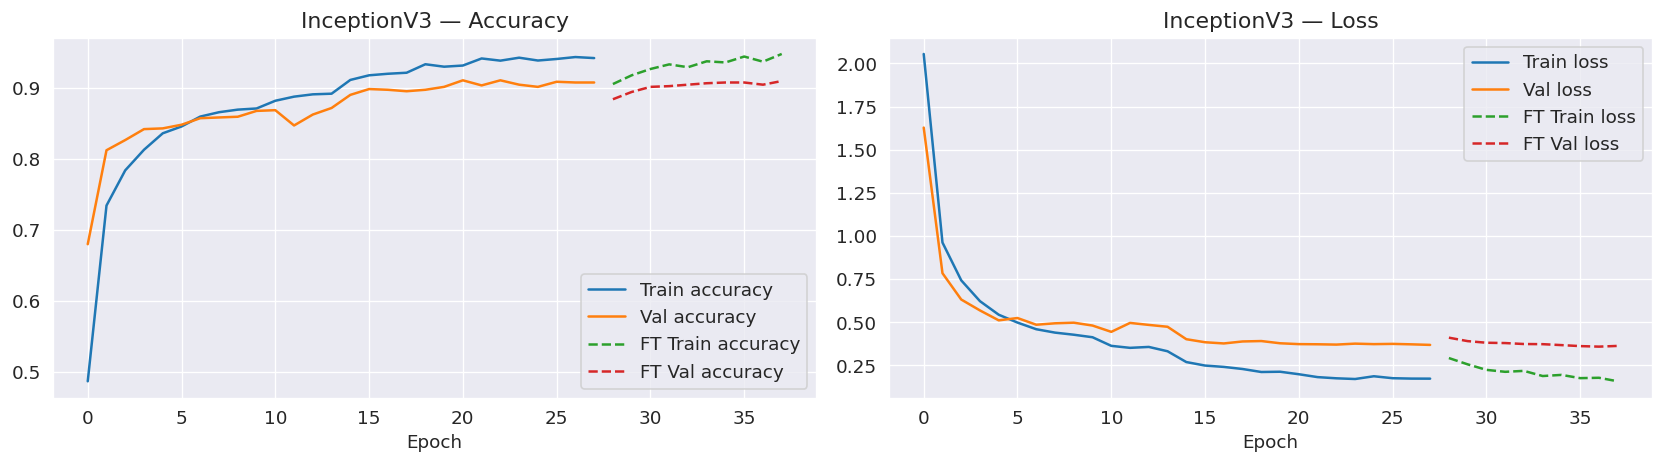


── InceptionV3 ──
  Accuracy  : 0.9097
  Precision : 0.9143
  Recall    : 0.9097
  F1-Score  : 0.9086


In [15]:
print('=' * 60)
print('  MODEL 5 : InceptionV3  (img_size=299)')
print('=' * 60)

train_gen_inc, val_gen_inc, test_gen_inc = make_generators(inc_preprocess, img_size=299)

model_inc = build_model(InceptionV3, inc_preprocess, img_size=299, model_name='InceptionV3')
model_inc.summary()

history_inc = model_inc.fit(
    train_gen_inc,
    epochs=EPOCHS,
    validation_data=val_gen_inc,
    callbacks=get_callbacks('InceptionV3'),
    verbose=1
)

history_inc_ft = fine_tune_model(model_inc, InceptionV3, train_gen_inc, val_gen_inc)

plot_history(history_inc, 'InceptionV3', history_inc_ft)
result_inc = evaluate_on_val(model_inc, val_gen_inc, 'InceptionV3')
all_results.append(result_inc)

## Model Comparisons



 Final Model Comparison (Validation Set)

                  accuracy  precision  recall      f1
model                                                
EfficientNetB3      0.9005     0.9036  0.9005  0.8988
ResNet50V2          0.9303     0.9339  0.9303  0.9297
MobileNetV3Large    0.9251     0.9296  0.9251  0.9238
DenseNet121         0.9333     0.9349  0.9333  0.9323
InceptionV3         0.9097     0.9143  0.9097  0.9086


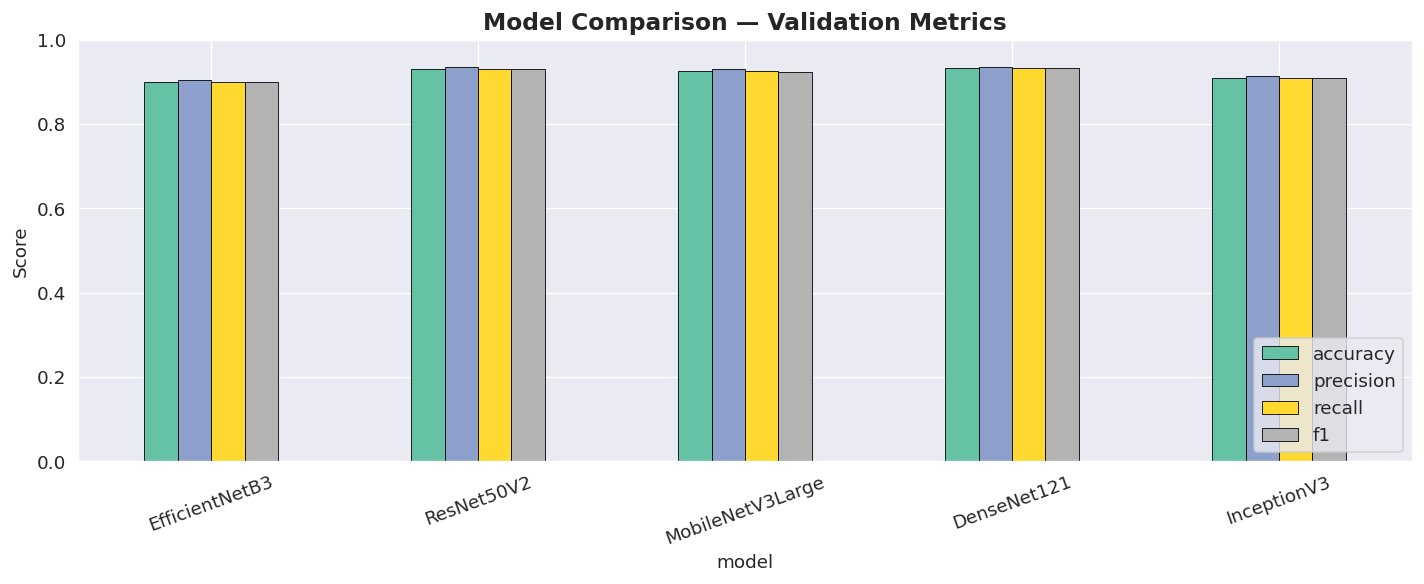

In [16]:
results_df = pd.DataFrame(all_results).set_index('model')
print('\n Final Model Comparison (Validation Set)\n')
print(results_df.round(4).to_string())

metrics = ['accuracy', 'precision', 'recall', 'f1']
results_df[metrics].plot(
    kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black', linewidth=0.5
)
plt.title('Model Comparison — Validation Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Confusion Matrix — Best Model


In [17]:
best_model_name = results_df['accuracy'].idxmax()
print(f'\n Best model : {best_model_name}  '
      f'(Val Accuracy = {results_df.loc[best_model_name, "accuracy"]:.4f})')

model_map = {
    'EfficientNetB3':   model_eff,
    'ResNet50V2':       model_res,
    'MobileNetV3Large': model_mob,
    'DenseNet121':      model_den,
    'InceptionV3':      model_inc,
}
val_gen_map = {
    'EfficientNetB3':   val_gen_eff,
    'ResNet50V2':       val_gen_res,
    'MobileNetV3Large': val_gen_mob,
    'DenseNet121':      val_gen_den,
    'InceptionV3':      val_gen_inc,
}
best_keras_model = model_map[best_model_name]
best_val_gen     = val_gen_map[best_model_name]


 Best model : DenseNet121  (Val Accuracy = 0.9333)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step


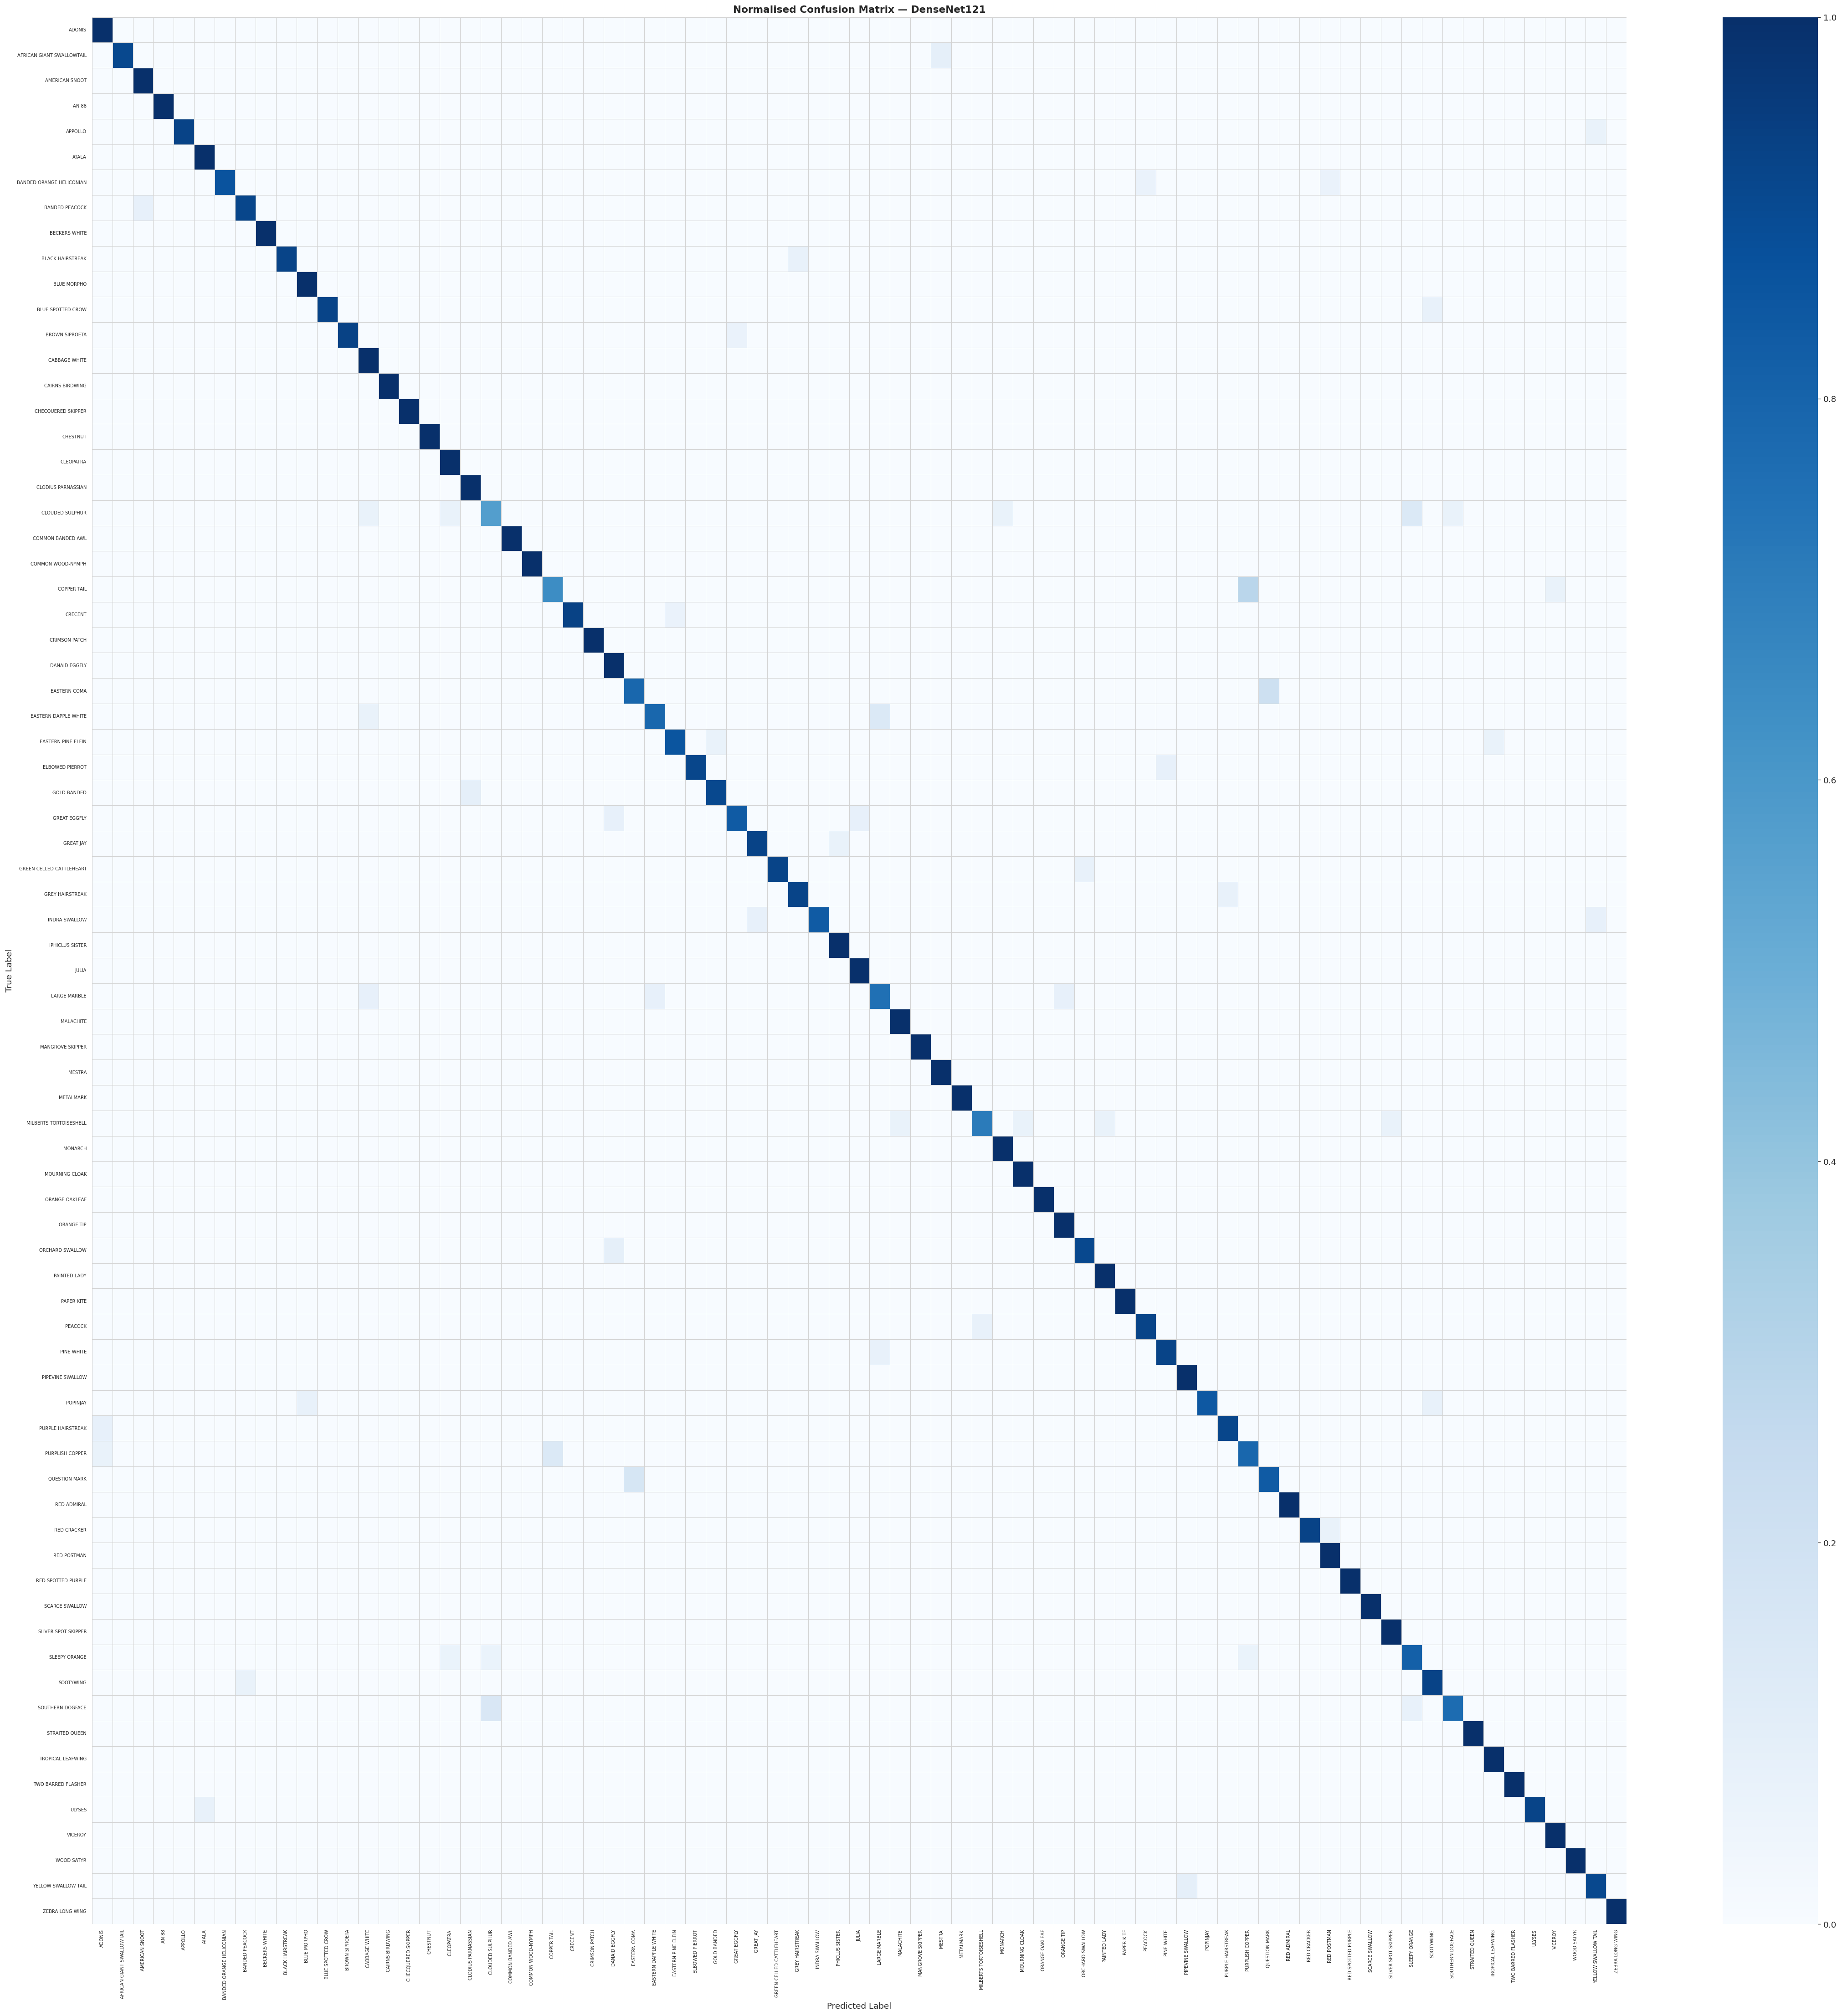


Classification Report:

                           precision    recall  f1-score   support

                   ADONIS       0.87      1.00      0.93        13
AFRICAN GIANT SWALLOWTAIL       1.00      0.91      0.95        11
           AMERICAN SNOOT       0.92      1.00      0.96        11
                    AN 88       1.00      1.00      1.00        13
                  APPOLLO       1.00      0.93      0.96        14
                    ATALA       0.94      1.00      0.97        15
 BANDED ORANGE HELICONIAN       1.00      0.87      0.93        15
           BANDED PEACOCK       0.92      0.92      0.92        12
            BECKERS WHITE       1.00      1.00      1.00        12
         BLACK HAIRSTREAK       1.00      0.92      0.96        13
              BLUE MORPHO       0.92      1.00      0.96        11
        BLUE SPOTTED CROW       1.00      0.92      0.96        13
           BROWN SIPROETA       1.00      0.93      0.97        15
            CABBAGE WHITE       0.82

In [18]:
best_val_gen.reset()
y_pred_prob_best = best_keras_model.predict(best_val_gen, verbose=1)
y_pred_best      = np.argmax(y_pred_prob_best, axis=1)
y_true_best      = best_val_gen.classes

cm = confusion_matrix(y_true_best, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES // 2), max(12, NUM_CLASSES // 2)))
sns.heatmap(
    cm_norm, annot=(NUM_CLASSES <= 30), fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    linewidths=0.3, linecolor='lightgrey'
)
ax.set_title(f'Normalised Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

print('\nClassification Report:\n')
print(classification_report(y_true_best, y_pred_best, target_names=CLASS_NAMES, zero_division=0))

## Save Best Model


In [19]:
import os
os.makedirs('model', exist_ok=True)

best_keras_model.save('model/butterfly.keras')
print(f' Saved Keras model  →  model/butterfly.keras')

 Saved Keras model  →  model/butterfly.keras


In [20]:
import pickle

best_img_size = 299 if best_model_name == 'InceptionV3' else 224

preprocess_map = {
    'EfficientNetB3':   'efficientnet',
    'ResNet50V2':       'resnet_v2',
    'MobileNetV3Large': 'mobilenet_v3',
    'DenseNet121':      'densenet',
    'InceptionV3':      'inception_v3',
}

meta = {
    'class_names':    CLASS_NAMES,
    'best_model':     best_model_name,
    'img_size':       best_img_size,
    'preprocess_key': preprocess_map[best_model_name],
    'num_classes':    NUM_CLASSES,
}

with open('model/butterfly.pkl', 'wb') as f:
    pickle.dump(meta, f)

print(f' Saved metadata pickle  →  model/butterfly.pkl')
print(f'   Class names : {CLASS_NAMES[:5]} ... ({NUM_CLASSES} total)')
print(f'   Best model  : {best_model_name}  |  img_size: {best_img_size}')

 Saved metadata pickle  →  model/butterfly.pkl
   Class names : ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO'] ... (75 total)
   Best model  : DenseNet121  |  img_size: 224
